1. Data Exploration (EDA)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("diabetes.csv")

In [3]:
# Summary statistics
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [4]:
# Check for missing values
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


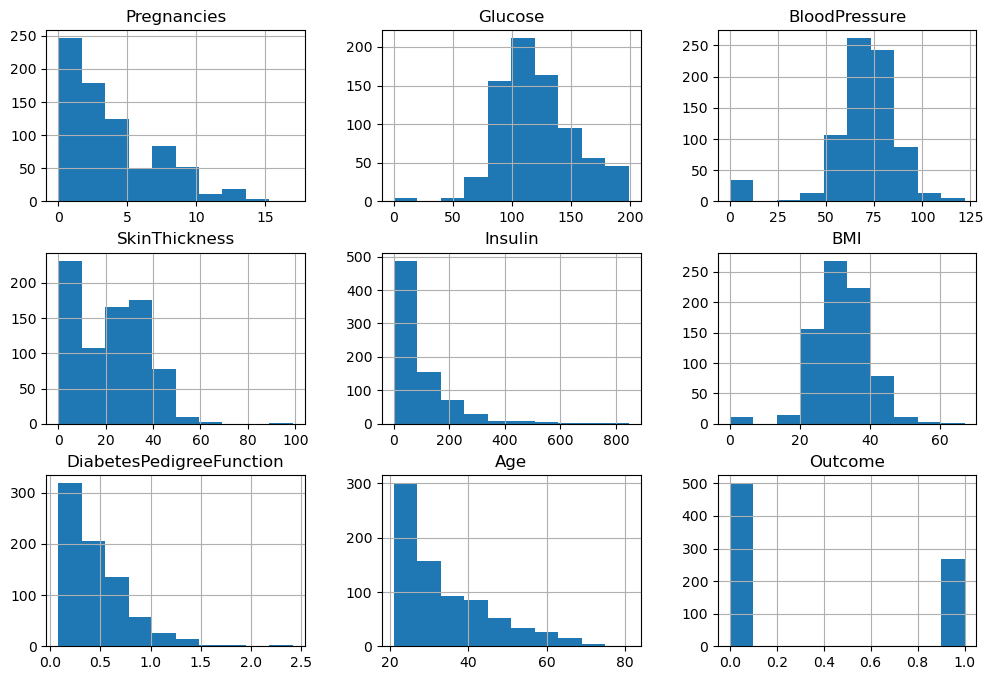

In [5]:
# Histograms
df.hist(figsize=(12,8))
plt.show()

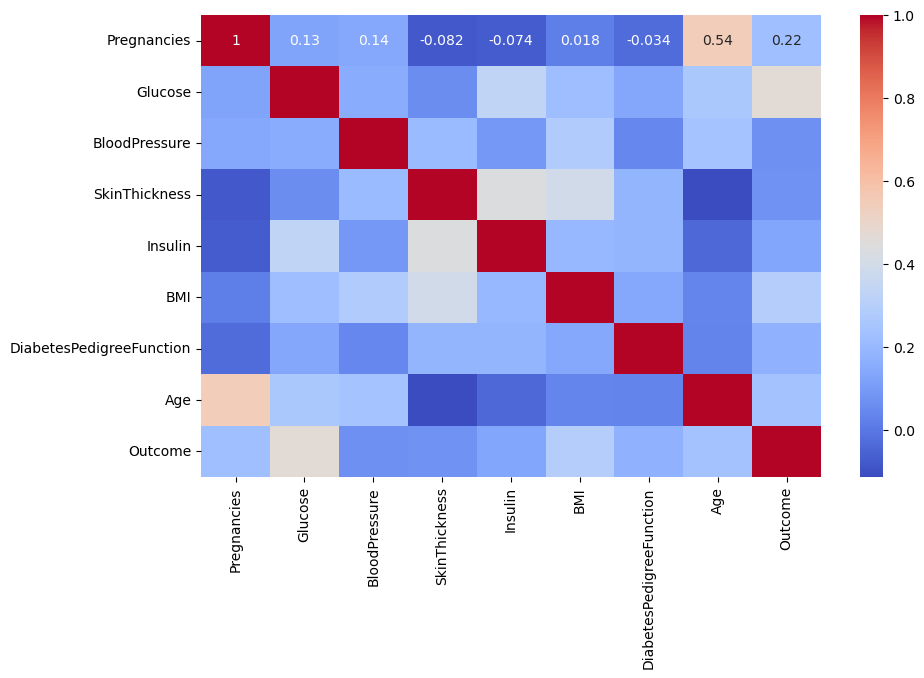

In [6]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

2. Data Preprocessing

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


3. Model Building

In [8]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

4. Model Evaluation

Accuracy: 0.7142857142857143

Confusion Matrix:
 [[82 18]
 [26 28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154

ROC-AUC Score: 0.8229629629629629


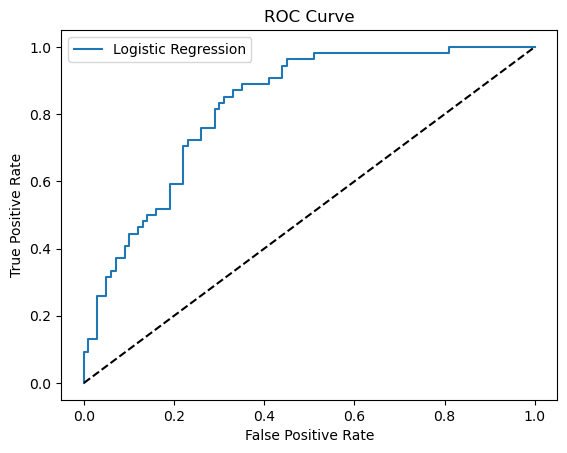

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


5. Interpretation

In [10]:
# Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(coefficients)


                    Feature  Coefficient
1                   Glucose     1.143826
5                       BMI     0.713810
0               Pregnancies     0.372997
6  DiabetesPedigreeFunction     0.255507
7                       Age     0.184135
3             SkinThickness     0.066424
4                   Insulin    -0.127291
2             BloodPressure    -0.197716


# Insights
Glucose and BMI dominate the model — they are the most influential predictors.

Pregnancies, family history, and age add moderate predictive power.

Insulin and Blood Pressure show negative coefficients, which may be due to missing values or multicollinearity (they overlap with other predictors).

Logistic regression coefficients don’t directly give probabilities; they show how each unit change in a feature shifts the log-odds of diabetes.

6. Deployment with Streamlit

In [11]:
#This will create the files log_reg_model.pkl and scaler.pkl in your working directory.
import pickle  

# Save model
with open("log_reg_model.pkl", "wb") as f:
    pickle.dump(log_reg, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


In [12]:
#Load them in Streamlit
import pickle

# Load trained model and scaler
model = pickle.load(open("log_reg_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))


In [13]:
%%writefile app.py
import streamlit as st
import numpy as np
import pickle

# Load trained model and scaler
model = pickle.load(open("log_reg_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

st.title("Diabetes Prediction App")

# User inputs
preg = st.number_input("Pregnancies", 0, 20)
glucose = st.number_input("Glucose", 0, 200)
bp = st.number_input("Blood Pressure", 0, 150)
skin = st.number_input("Skin Thickness", 0, 100)
insulin = st.number_input("Insulin", 0, 900)
bmi = st.number_input("BMI", 0.0, 70.0)
dpf = st.number_input("Diabetes Pedigree Function", 0.0, 3.0)
age = st.number_input("Age", 0, 100)

if st.button("Predict"):
    input_data = np.array([[preg, glucose, bp, skin, insulin, bmi, dpf, age]])
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)[0]
    st.write("Outcome:", "Diabetic" if prediction==1 else "Non-Diabetic")


Writing app.py


after above steps to Run the App in Command Prompt use this code "cd C:\Users\malip\OneDrive\Documents\onda
python -m streamlit run app.py" and see the result


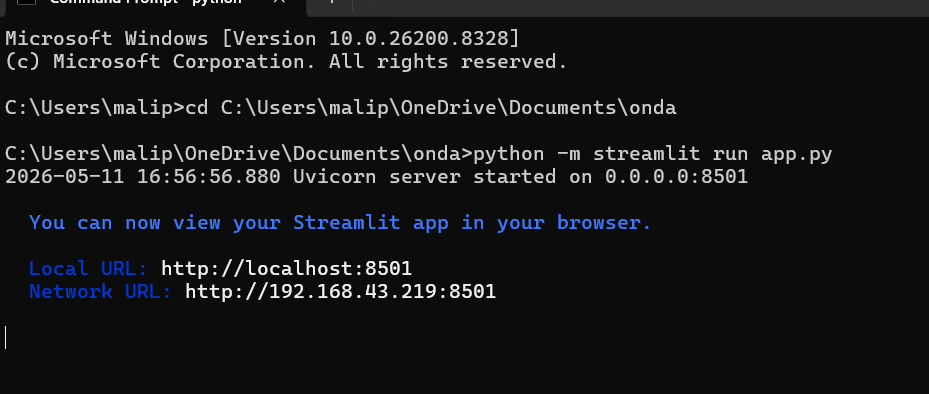

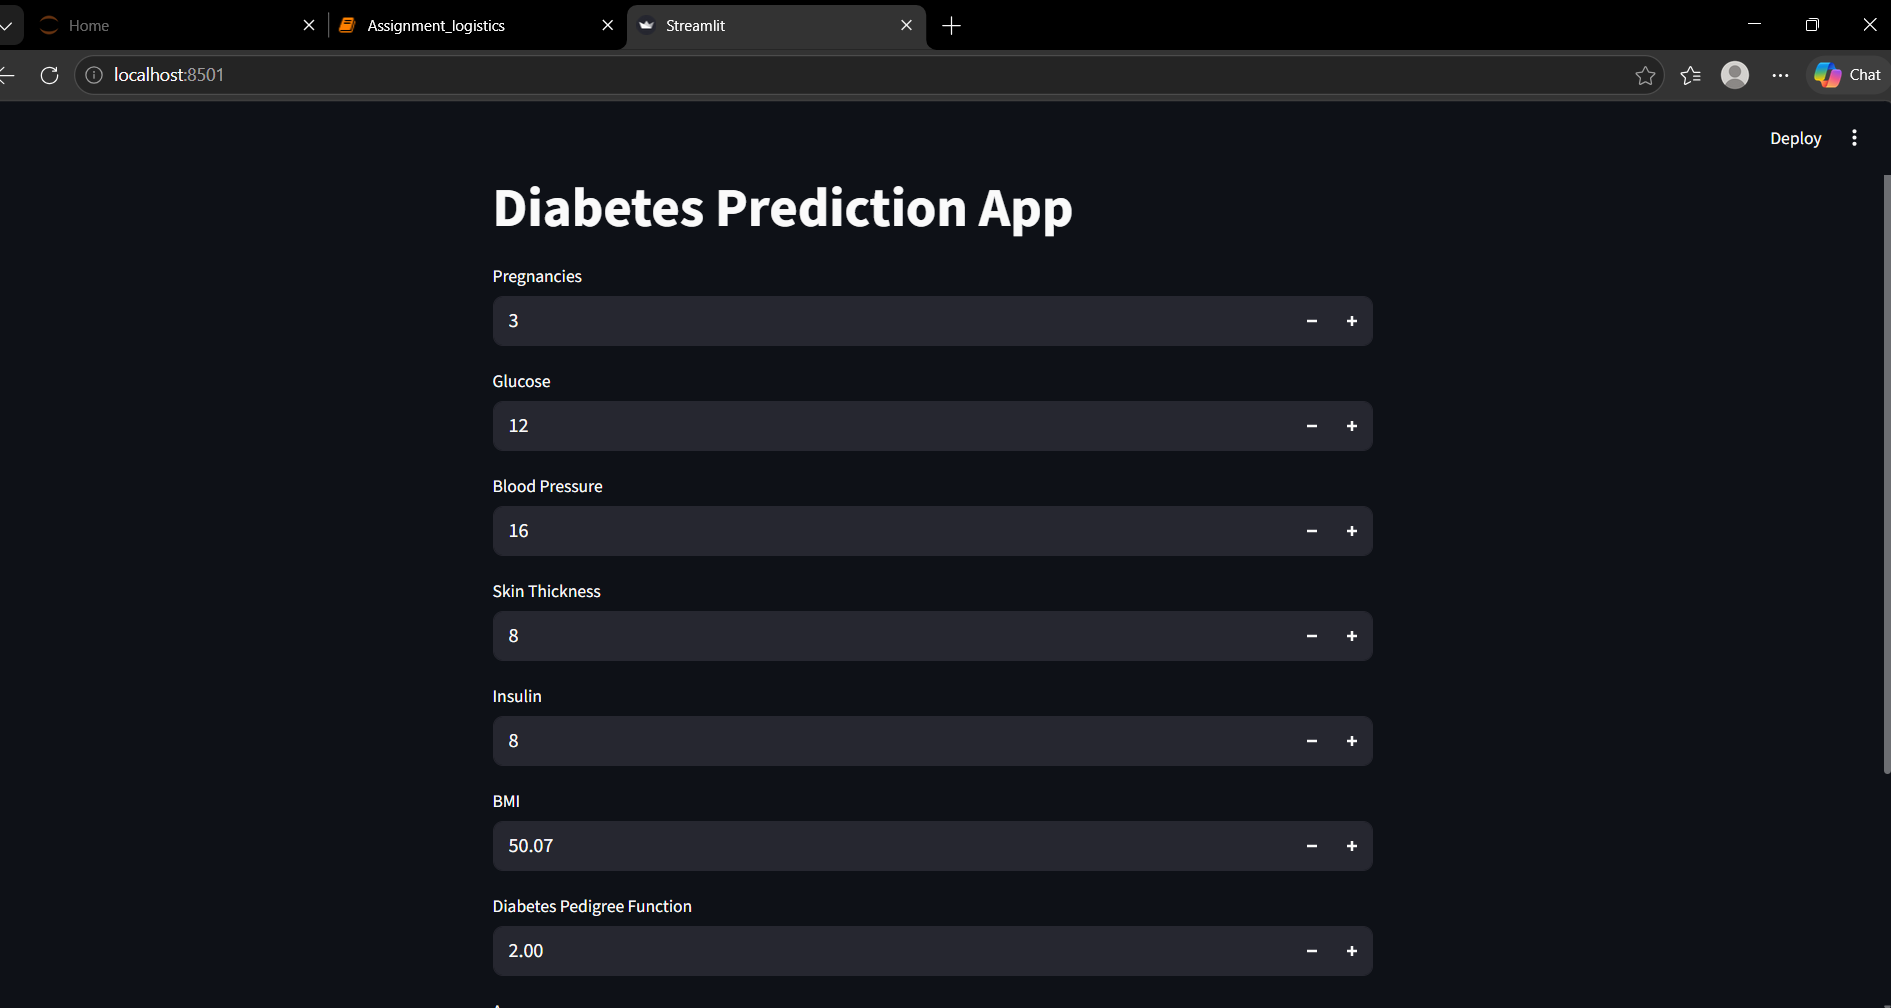
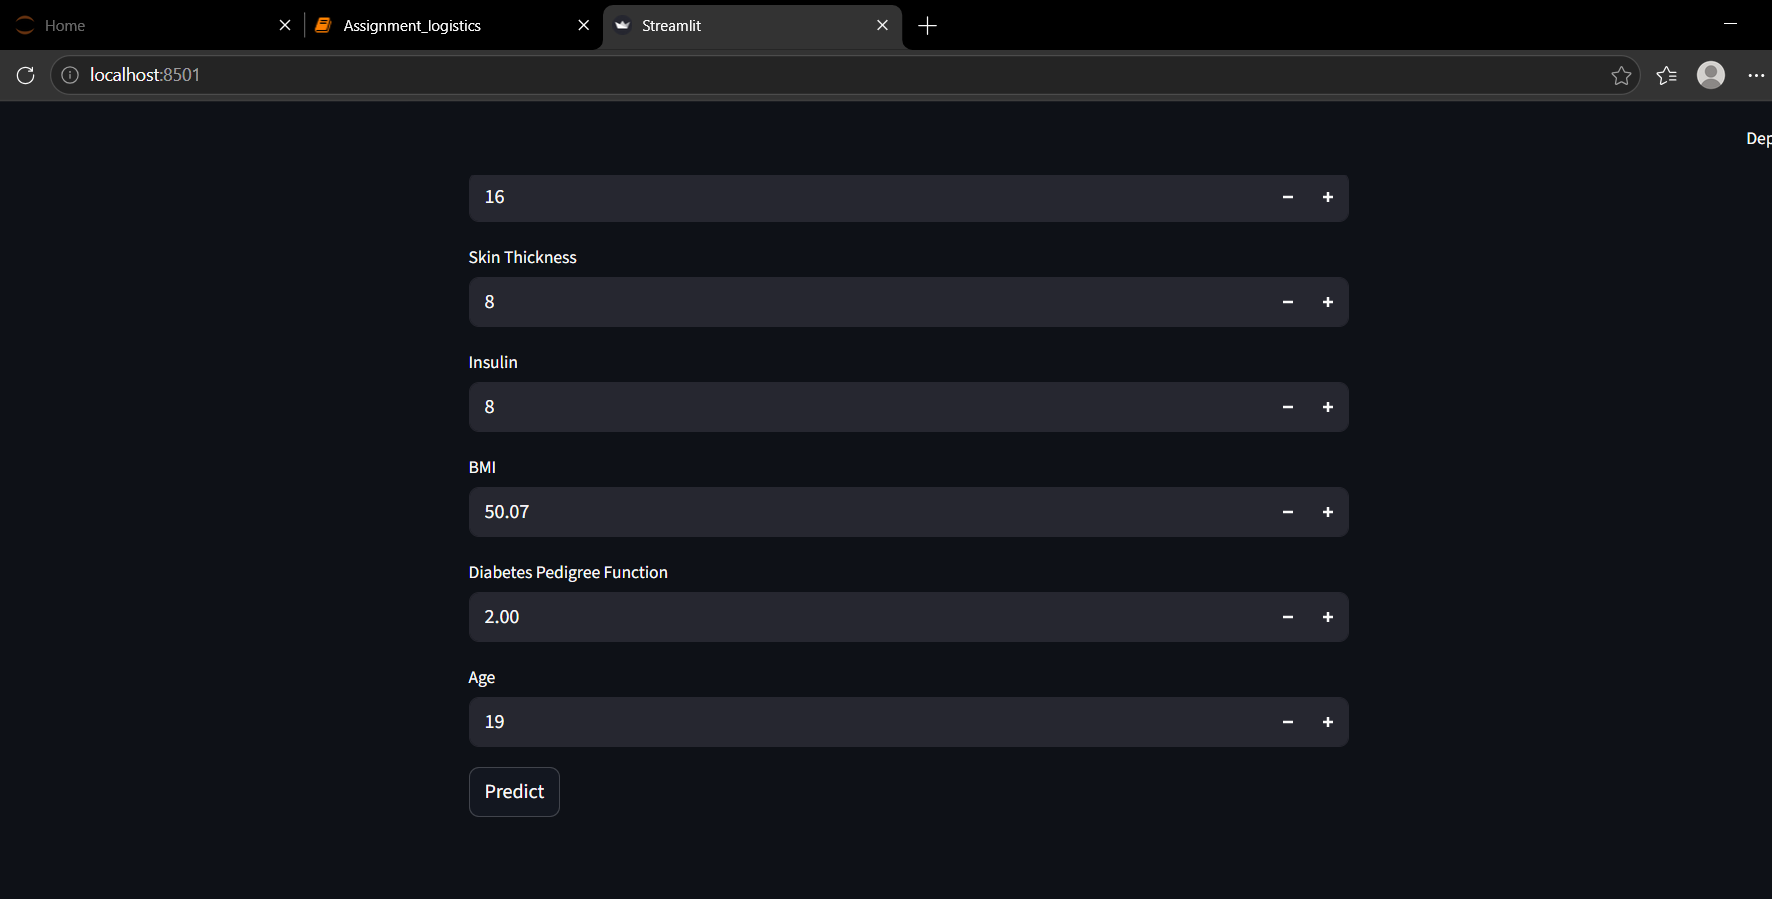

# Now see the Outcome
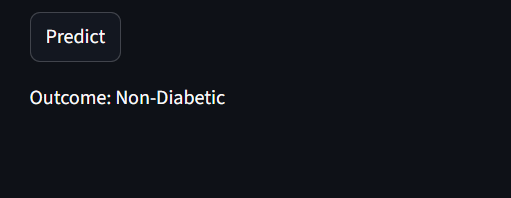